In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Tilapia Fresh and Non Fresh Image Dataset.zip to Tilapia Fresh and Non Fresh Image Dataset.zip


In [5]:
import os

base_path = "/content/fish_dataset/extracted"

for root, dirs, files in os.walk(base_path):

    level = root.replace(base_path, "").count(os.sep)

    if level <= 2:

        print("  " * level + os.path.basename(root) + "/")

        for file in files[:5]:
            print("  " * (level + 1) + file)

In [6]:
image_extensions = (
    ".jpg", ".jpeg", ".png",
    ".JPG", ".JPEG", ".PNG"
)

class_folders = []

for root, dirs, files in os.walk(base_path):

    image_count = sum(
        1 for f in files
        if f.endswith(image_extensions)
    )

    if image_count > 0:
        class_folders.append(
            (root, image_count)
        )

for folder, count in class_folders:
    print(
        folder,
        "->",
        count,
        "images"
    )

In [7]:
DATASET_PATH = "/content/fish_dataset/extracted"

print(
    "Dataset path:",
    DATASET_PATH
)

Dataset path: /content/fish_dataset/extracted


In [9]:
import os
import zipfile

# Find the ZIP file uploaded to Colab
zip_files = [
    name for name in os.listdir("/content")
    if name.lower().endswith(".zip")
]

print("ZIP files found:", zip_files)

if not zip_files:
    raise FileNotFoundError(
        "No ZIP file found. Please upload your Kaggle ZIP again."
    )

# Use the uploaded ZIP file
zip_path = os.path.join("/content", zip_files[0])

# Extract the dataset
extract_path = "/content/fish_dataset"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Extracted location:", extract_path)

ZIP files found: ['Tilapia Fresh and Non Fresh Image Dataset.zip']
Dataset extracted successfully!
Extracted location: /content/fish_dataset


In [10]:
import os

for root, dirs, filenames in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)

    if level <= 3:
        print("  " * level + os.path.basename(root) + "/")

        for filename in filenames[:4]:
            print("  " * (level + 1) + filename)

fish_dataset/
  Kaggle_upload/
    Fresh_Day1/
      Gills/
      Eyes/
    NonFresh/
      Day 3/
      Day 4/
      Day 2/


In [11]:
from collections import Counter

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for root, dirs, filenames in os.walk(extract_path):
    image_files = [
        f for f in filenames
        if f.lower().endswith(image_extensions)
    ]

    if image_files:
        print(f"{root}: {len(image_files)} images")

/content/fish_dataset/Kaggle_upload/Fresh_Day1/Gills/2_Gills_Day1: 500 images
/content/fish_dataset/Kaggle_upload/Fresh_Day1/Gills/1_Gills_Day1: 154 images
/content/fish_dataset/Kaggle_upload/Fresh_Day1/Gills/3_Gills_Day1: 225 images
/content/fish_dataset/Kaggle_upload/Fresh_Day1/Eyes/1_Eyes: 244 images
/content/fish_dataset/Kaggle_upload/Fresh_Day1/Eyes/3_Eyes: 500 images
/content/fish_dataset/Kaggle_upload/Fresh_Day1/Eyes/4_Eyes: 227 images
/content/fish_dataset/Kaggle_upload/Fresh_Day1/Eyes/5_Eyes: 492 images
/content/fish_dataset/Kaggle_upload/Fresh_Day1/Eyes/6_Eyes: 417 images
/content/fish_dataset/Kaggle_upload/Fresh_Day1/Eyes/7_Eyes: 203 images
/content/fish_dataset/Kaggle_upload/Fresh_Day1/Eyes/2_Eyes: 360 images
/content/fish_dataset/Kaggle_upload/NonFresh/Day 3/Gills: 500 images
/content/fish_dataset/Kaggle_upload/NonFresh/Day 3/Eyes: 496 images
/content/fish_dataset/Kaggle_upload/NonFresh/Day 4/Gills: 500 images
/content/fish_dataset/Kaggle_upload/NonFresh/Day 4/Eyes: 501 im

In [12]:
import os
import pandas as pd

base_path = "/content/fish_dataset/Kaggle_upload"
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

records = []

for root, dirs, filenames in os.walk(base_path):
    for filename in filenames:
        if filename.lower().endswith(image_extensions):
            parts = os.path.relpath(
                os.path.join(root, filename),
                base_path
            ).split(os.sep)

            top_folder = parts[0].strip().lower()

            if top_folder.startswith("fresh"):
                label = "Fresh"
            elif top_folder.startswith("nonfresh"):
                label = "Non-Fresh"
            else:
                continue

            records.append({
                "filepath": os.path.join(root, filename),
                "relative_path": os.path.join(*parts),
                "label": label
            })

df = pd.DataFrame(records)

if df.empty:
    raise ValueError("No images found. Check the dataset path.")

print("Total images:", len(df))
print("\nImages per class:")
print(df["label"].value_counts())

print("\nFirst five records:")
display(df.head())

df.to_csv("/content/fish_image_index.csv", index=False)
print("\nImage index saved successfully.")

Total images: 5719

Images per class:
label
Fresh        3322
Non-Fresh    2397
Name: count, dtype: int64

First five records:


,filepath,relative_path,label
0,/content/fish_dataset/Kaggle_upload/Fresh_Day1...,Fresh_Day1/Gills/2_Gills_Day1/0321.jpg,Fresh
1,/content/fish_dataset/Kaggle_upload/Fresh_Day1...,Fresh_Day1/Gills/2_Gills_Day1/0139.jpg,Fresh
2,/content/fish_dataset/Kaggle_upload/Fresh_Day1...,Fresh_Day1/Gills/2_Gills_Day1/0375.jpg,Fresh
3,/content/fish_dataset/Kaggle_upload/Fresh_Day1...,Fresh_Day1/Gills/2_Gills_Day1/0029.jpg,Fresh
4,/content/fish_dataset/Kaggle_upload/Fresh_Day1...,Fresh_Day1/Gills/2_Gills_Day1/0425.jpg,Fresh



Image index saved successfully.


In [13]:
from google.colab import files

files.download("/content/fish_image_index.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Class,Number of Images
0,Fresh,3322
1,Non-Fresh,2397
2,Total,5719


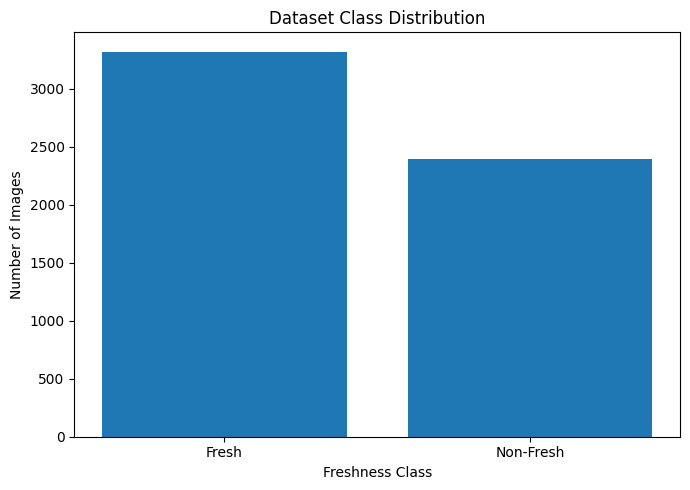

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import matplotlib.pyplot as plt

class_counts = df["label"].value_counts().reindex(
    ["Fresh", "Non-Fresh"],
    fill_value=0
)

distribution_table = pd.DataFrame({
    "Class": class_counts.index,
    "Number of Images": class_counts.values
})

distribution_table.loc[len(distribution_table)] = [
    "Total",
    int(class_counts.sum())
]

display(distribution_table)

distribution_table.to_csv(
    "/content/dataset_distribution.csv",
    index=False
)

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Freshness Class")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.tight_layout()
plt.savefig(
    "/content/dataset_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

files.download("/content/dataset_distribution.csv")
files.download("/content/dataset_distribution.png")

In [16]:
import os
import pandas as pd

base_path = "/content/fish_dataset/Kaggle_upload"
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

records = []

for root, dirs, filenames in os.walk(base_path):
    for filename in filenames:
        if not filename.lower().endswith(image_extensions):
            continue

        full_path = os.path.join(root, filename)
        relative_path = os.path.relpath(full_path, base_path)
        first_folder = relative_path.split(os.sep)[0].lower()

        if first_folder.startswith("fresh") and not first_folder.startswith("nonfresh"):
            label = "Fresh"
        elif first_folder.startswith("nonfresh"):
            label = "Non-Fresh"
        else:
            continue

        records.append({
            "filepath": full_path,
            "relative_path": relative_path,
            "label": label
        })

df = pd.DataFrame(
    records,
    columns=["filepath", "relative_path", "label"]
)

print("Columns:", df.columns.tolist())
print("Total images:", len(df))

if len(df) == 0:
    print("No images found. Check the dataset folder path.")
else:
    print("\nImages per class:")
    print(df["label"].value_counts())
    display(df.head())

Columns: ['filepath', 'relative_path', 'label']
Total images: 5719

Images per class:
label
Fresh        3322
Non-Fresh    2397
Name: count, dtype: int64


,filepath,relative_path,label
0,/content/fish_dataset/Kaggle_upload/Fresh_Day1...,Fresh_Day1/Gills/2_Gills_Day1/0321.jpg,Fresh
1,/content/fish_dataset/Kaggle_upload/Fresh_Day1...,Fresh_Day1/Gills/2_Gills_Day1/0139.jpg,Fresh
2,/content/fish_dataset/Kaggle_upload/Fresh_Day1...,Fresh_Day1/Gills/2_Gills_Day1/0375.jpg,Fresh
3,/content/fish_dataset/Kaggle_upload/Fresh_Day1...,Fresh_Day1/Gills/2_Gills_Day1/0029.jpg,Fresh
4,/content/fish_dataset/Kaggle_upload/Fresh_Day1...,Fresh_Day1/Gills/2_Gills_Day1/0425.jpg,Fresh


In [17]:
from google.colab import files

df.to_csv("/content/fish_image_index.csv", index=False)

files.download("/content/fish_image_index.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Class,Number of Images
0,Fresh,3322
1,Non-Fresh,2397
2,Total,5719


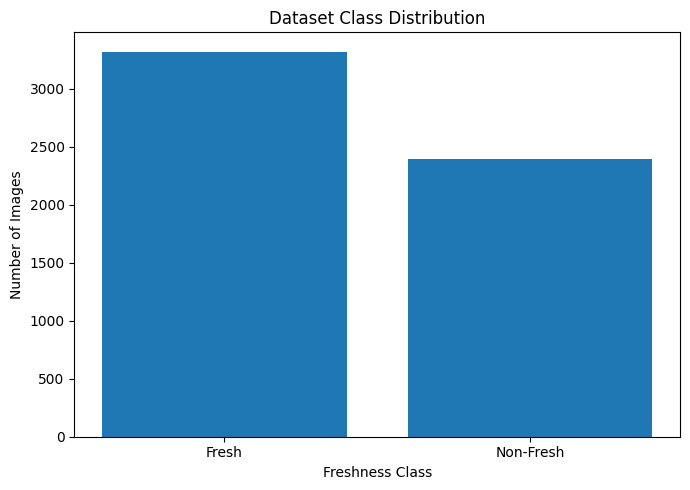

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import matplotlib.pyplot as plt

class_counts = df["label"].value_counts().reindex(
    ["Fresh", "Non-Fresh"],
    fill_value=0
)

distribution_table = pd.DataFrame({
    "Class": class_counts.index,
    "Number of Images": class_counts.values
})

distribution_table.loc[len(distribution_table)] = [
    "Total", int(class_counts.sum())
]

display(distribution_table)

distribution_table.to_csv(
    "/content/dataset_distribution.csv",
    index=False
)

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Freshness Class")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.tight_layout()
plt.savefig("/content/dataset_distribution.png", dpi=300)
plt.show()

files.download("/content/dataset_distribution.csv")
files.download("/content/dataset_distribution.png")

In [19]:
print("Total images:", len(df))
print("\nClass counts:")
print(df["label"].value_counts())

print("\nColumns:")
print(df.columns.tolist())

Total images: 5719

Class counts:
label
Fresh        3322
Non-Fresh    2397
Name: count, dtype: int64

Columns:
['filepath', 'relative_path', 'label']


/tmp/ipykernel_432/605296787.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby("label", group_keys=False).apply(


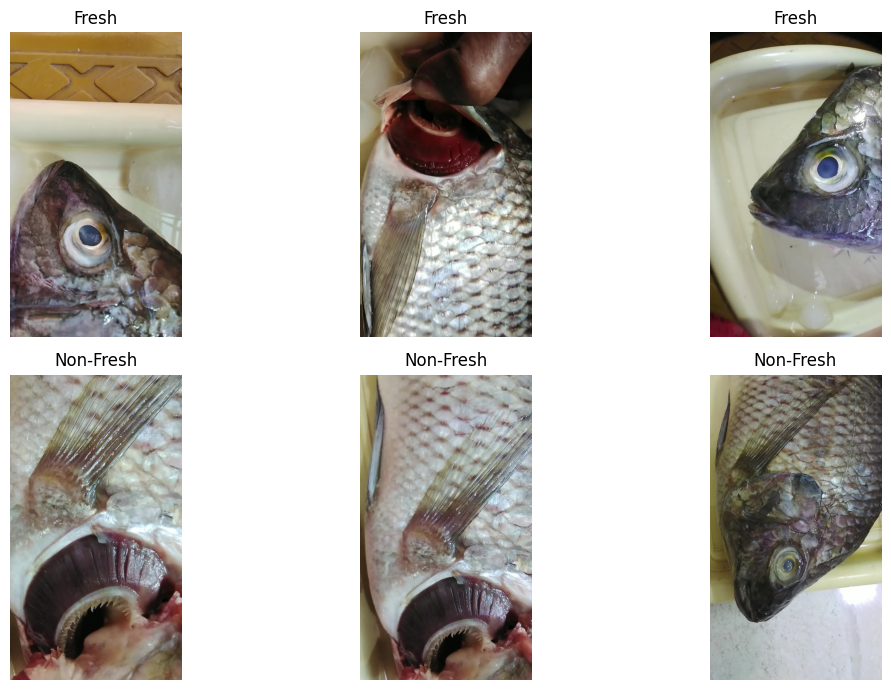

In [20]:
from PIL import Image

sample_df = df.groupby("label", group_keys=False).apply(
    lambda group: group.sample(
        n=min(3, len(group)),
        random_state=42
    )
).reset_index(drop=True)

plt.figure(figsize=(12, 7))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["filepath"]).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/content/sample_fish_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
files.download("/content/sample_fish_images.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from sklearn.model_selection import train_test_split

# Shuffle and split the image index
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTraining class counts:")
print(train_df["label"].value_counts())

print("\nValidation class counts:")
print(val_df["label"].value_counts())

print("\nTest class counts:")
print(test_df["label"].value_counts())

# Save split records for reproducibility
train_df.to_csv("/content/train_split.csv", index=False)
val_df.to_csv("/content/validation_split.csv", index=False)
test_df.to_csv("/content/test_split.csv", index=False)

Training images: 4003
Validation images: 858
Test images: 858

Training class counts:
label
Fresh        2325
Non-Fresh    1678
Name: count, dtype: int64

Validation class counts:
label
Fresh        498
Non-Fresh    360
Name: count, dtype: int64

Test class counts:
label
Fresh        499
Non-Fresh    359
Name: count, dtype: int64


In [23]:
from google.colab import files

files.download("/content/train_split.csv")
files.download("/content/validation_split.csv")
files.download("/content/test_split.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from google.colab import files

print("TensorFlow version:", tf.__version__)
print("Available GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
Available GPU: []


In [25]:
CLASS_NAMES = ["Fresh", "Non-Fresh"]

LABEL_MAP = {
    "Fresh": 0,
    "Non-Fresh": 1
}

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

def encode_labels(dataframe):
    return dataframe["label"].map(LABEL_MAP).to_numpy(dtype=np.int32)

print("Label mapping:", LABEL_MAP)

Label mapping: {'Fresh': 0, 'Non-Fresh': 1}


In [26]:
def load_image(path, label):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label


def make_dataset(dataframe, training=False):
    paths = dataframe["filepath"].to_numpy()
    labels = encode_labels(dataframe)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Datasets prepared.")

Datasets prepared.


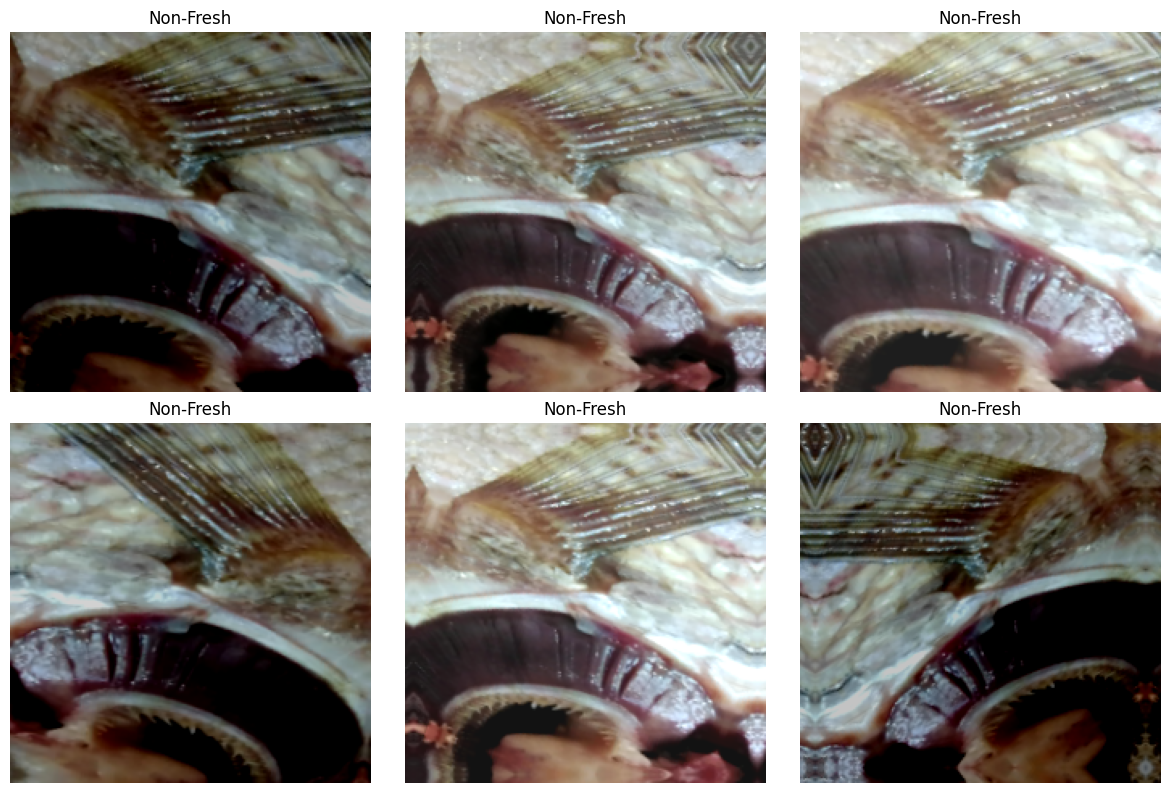

In [27]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.25),
    layers.RandomBrightness(0.25, value_range=(0, 255))
], name="data_augmentation")

for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 8))

    for i in range(6):
        augmented = data_augmentation(
            images[:1],
            training=True
        )[0]

        augmented = tf.clip_by_value(
            augmented / 255.0, 0, 1
        )

        plt.subplot(2, 3, i + 1)
        plt.imshow(augmented.numpy())
        plt.title(CLASS_NAMES[int(labels[0].numpy())])
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(
        "/content/lighting_variations.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    break

In [28]:
files.download("/content/lighting_variations.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 feature extractor loaded.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 feature extractor loaded.


In [30]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid",
    name="freshness_probability"
)(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ freshness_probability (Dense)   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
EPOCHS = 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_fish_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Training completed.")

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.7320 - loss: 0.5326 - val_accuracy: 0.8788 - val_loss: 0.3757
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.8599 - loss: 0.3549 - val_accuracy: 0.9277 - val_loss: 0.2736
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9143 - loss: 0.2639 - val_accuracy: 0.9452 - val_loss: 0.2092
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.9475 - loss: 0.2013 - val_accuracy: 0.9592 - val_loss: 0.1717
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9585 - loss: 0.1659 - val_accuracy: 0.9779 - val_loss: 0.1456
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.9645 - loss: 0.1455 - val_accuracy: 0.9895 - val_loss: 0.1253
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9725 - loss: 0.1271 - val_accuracy: 0.9930 - val_loss: 0.1086
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9798 - loss: 0.1061 - val_accu

In [32]:
history_df = pd.DataFrame(history.history)

history_df.insert(
    0,
    "Epoch",
    range(1, len(history_df) + 1)
)

history_df.to_csv(
    "/content/training_history.csv",
    index=False
)

display(history_df)

files.download("/content/training_history.csv")

,Epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.731951,0.532592,0.878788,0.375651
1,2,0.859855,0.354921,0.927739,0.273551
2,3,0.914314,0.263895,0.945221,0.209239
3,4,0.947539,0.201298,0.959207,0.171740
4,5,0.958531,0.165885,0.977856,0.145591
5,6,0.964527,0.145530,0.989510,0.125345
6,7,0.972521,0.127112,0.993007,0.108572
7,8,0.979765,0.106086,0.996503,0.096213
8,9,0.983512,0.092295,0.998834,0.084631
9,10,0.981514,0.093070,0.997669,0.077896


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

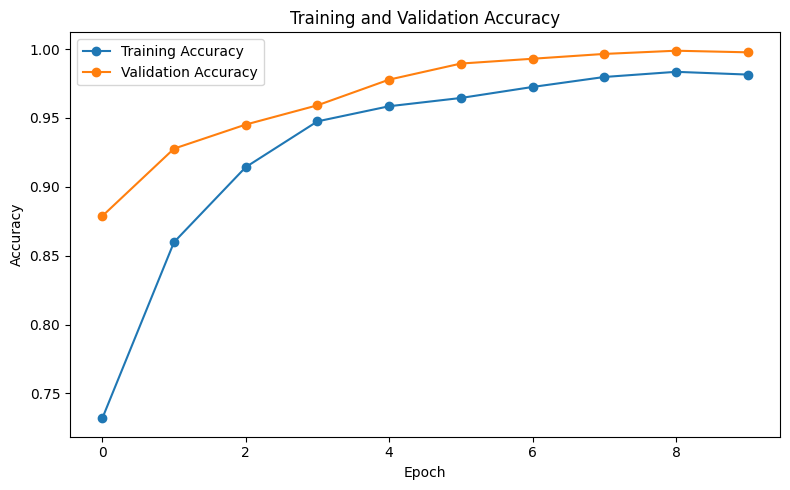

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("/content/training_validation_accuracy.png")

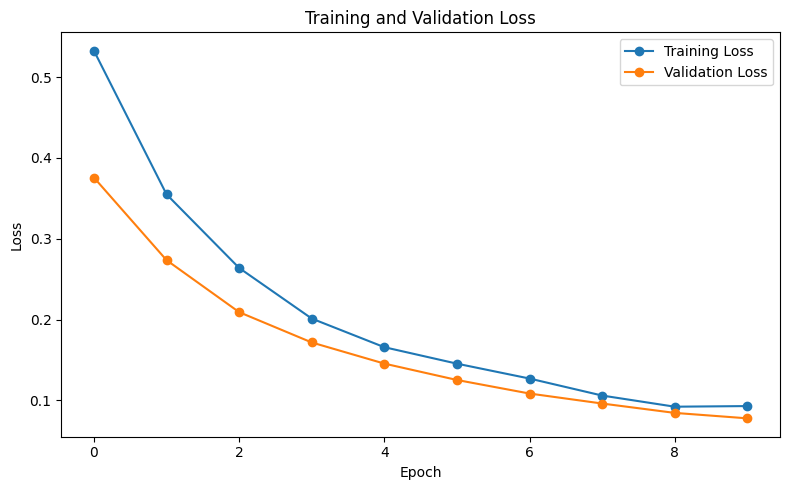

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("/content/training_validation_loss.png")

In [35]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9930 - loss: 0.0745
Test Loss: 0.0745
Test Accuracy: 0.9930


In [36]:
test_metrics = pd.DataFrame([{
    "Test Loss": test_loss,
    "Test Accuracy": test_accuracy
}])

test_metrics.to_csv(
    "/content/test_metrics.csv",
    index=False
)

display(test_metrics)
files.download("/content/test_metrics.csv")

,Test Loss,Test Accuracy
0,0.074527,0.993007


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
y_true = []
y_scores = []

for images, labels in test_ds:
    scores = model.predict(images, verbose=0).flatten()

    y_true.extend(labels.numpy().tolist())
    y_scores.extend(scores.tolist())

y_true = np.array(y_true, dtype=int)
y_scores = np.array(y_scores)

y_pred = (y_scores >= 0.5).astype(int)

print("Number of test predictions:", len(y_pred))
print("Predictions generated successfully.")

Number of test predictions: 858
Predictions generated successfully.


In [38]:
report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_csv(
    "/content/classification_report.csv",
    index=True,
    index_label="Class"
)

files.download("/content/classification_report.csv")

,precision,recall,f1-score,support
Fresh,0.990060,0.997996,0.994012,499.000000
Non-Fresh,0.997183,0.986072,0.991597,359.000000
accuracy,0.993007,0.993007,0.993007,0.993007
macro avg,0.993621,0.992034,0.992804,858.000000
weighted avg,0.993040,0.993007,0.993001,858.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

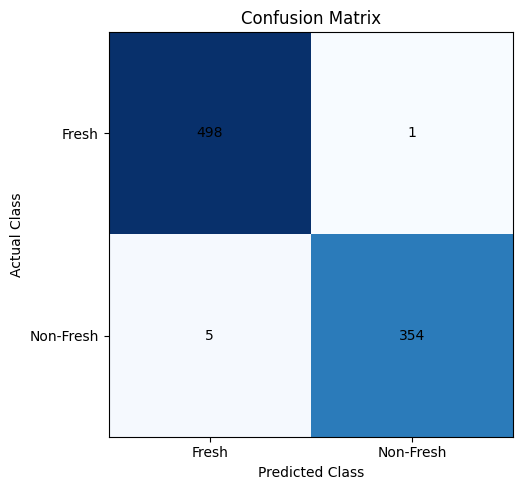

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], CLASS_NAMES)
plt.yticks([0, 1], CLASS_NAMES)

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()

plt.savefig(
    "/content/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("/content/confusion_matrix.png")

In [40]:
def change_brightness(images, factor):
    images = tf.cast(images, tf.float32)
    return tf.clip_by_value(images * factor, 0, 255)


def change_contrast(images, factor):
    images = tf.image.adjust_contrast(
        tf.cast(images, tf.float32),
        factor
    )
    return tf.clip_by_value(images, 0, 255)

In [41]:
def evaluate_lighting_condition(dataset, transformation=None):
    actual = []
    predicted = []

    for images, labels in dataset:
        images = tf.cast(images, tf.float32)

        if transformation is not None:
            images = transformation(images)

        scores = model.predict(images, verbose=0).flatten()
        predictions = (scores >= 0.5).astype(int)

        actual.extend(labels.numpy().tolist())
        predicted.extend(predictions.tolist())

    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(
            actual, predicted, zero_division=0
        ),
        "Recall": recall_score(
            actual, predicted, zero_division=0
        ),
        "F1 Score": f1_score(
            actual, predicted, zero_division=0
        )
    }

In [42]:
lighting_conditions = {
    "Normal": None,
    "Dark": lambda x: change_brightness(x, 0.5),
    "Bright": lambda x: change_brightness(x, 1.5),
    "Low Contrast": lambda x: change_contrast(x, 0.5),
    "High Contrast": lambda x: change_contrast(x, 1.5)
}

lighting_records = []

for condition, transformation in lighting_conditions.items():
    print("Evaluating:", condition)

    metrics = evaluate_lighting_condition(
        test_ds,
        transformation
    )

    lighting_records.append({
        "Lighting Condition": condition,
        **metrics
    })

results = pd.DataFrame(lighting_records)

display(results)

Evaluating: Normal
Evaluating: Dark
Evaluating: Bright
Evaluating: Low Contrast
Evaluating: High Contrast


,Lighting Condition,Accuracy,Precision,Recall,F1 Score
0,Normal,0.993007,0.997183,0.986072,0.991597
1,Dark,0.974359,0.988406,0.949861,0.968750
2,Bright,0.975524,1.000000,0.941504,0.969871
3,Low Contrast,0.954545,0.996894,0.894150,0.942731
4,High Contrast,0.986014,1.000000,0.966574,0.983003


In [43]:
results.to_csv(
    "/content/lighting_variation_results.csv",
    index=False
)

files.download("/content/lighting_variation_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

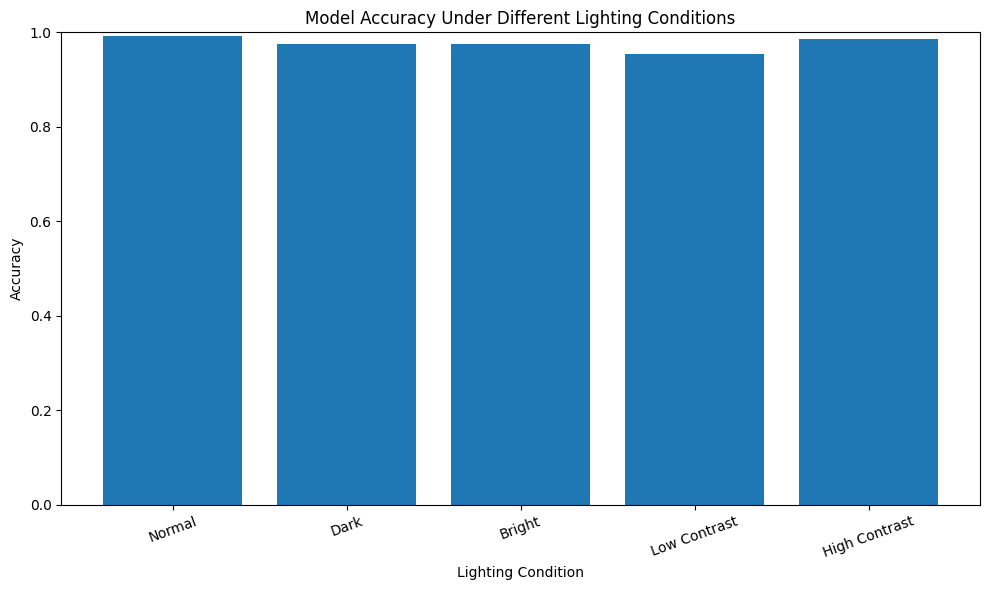

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Lighting Condition"],
    results["Accuracy"]
)

plt.xlabel("Lighting Condition")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Under Different Lighting Conditions")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "/content/lighting_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("/content/lighting_accuracy_comparison.png")

In [45]:
model.save("/content/Fish_Freshness_MobileNetV2.keras")

print("Model saved successfully.")

files.download("/content/Fish_Freshness_MobileNetV2.keras")

Model saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
uploaded = files.upload()

image_files = [
    name for name in uploaded
    if name.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )
]

if not image_files:
    raise ValueError("Please upload a supported fish image.")

image_path = image_files[0]

img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

score = float(model.predict(img_array, verbose=0)[0][0])

predicted_class = "Non-Fresh" if score >= 0.5 else "Fresh"

print("Predicted class:", predicted_class)
print(f"Non-Fresh probability: {score:.4f}")

Saving 41598_2021_96476_Fig4_HTML.png to 41598_2021_96476_Fig4_HTML.png
Predicted class: Fresh
Non-Fresh probability: 0.0148


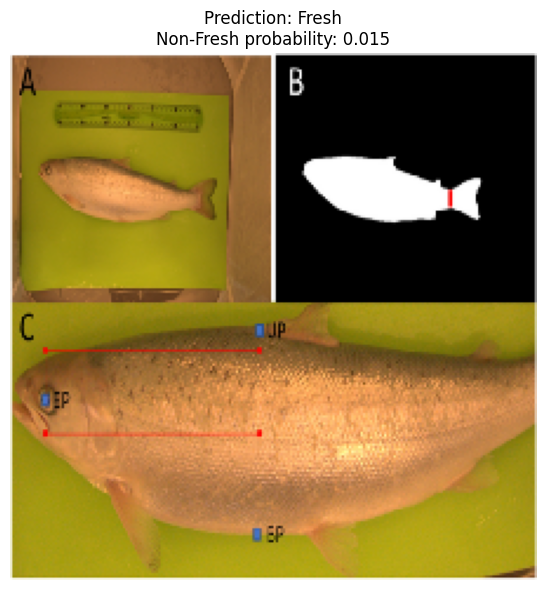

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Non-Fresh probability: {score:.3f}"
)
plt.tight_layout()

plt.savefig(
    "/content/test_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("/content/test_prediction.png")